# Algoritmos supervisados o semi-supervisados: Usando los datos de K-Means

In [1]:
from pyspark.sql import SparkSession

# 1. Iniciamos Spark en este nuevo notebook
spark = SparkSession.builder.appName("Semana12_Supervisados").getOrCreate()

# 2. Leemos DIRECTAMENTE los datos que guardamos en el Paso 1
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# 4. Mostramos la tabla para comprobar que TODO está ahí (Adaptado a tus columnas reales)
df_clusters.select("ciudad", "precio_limpio", "puntuacion", "prediction").show(10)

+------+-------------+----------+----------+
|ciudad|precio_limpio|puntuacion|prediction|
+------+-------------+----------+----------+
|     4|          0.0|       8.6|         1|
|     4|          0.0|       8.3|         1|
|     4|          0.0|       8.9|         1|
|     4|          0.0|       8.6|         1|
|     4|          0.0|       0.0|         0|
|     4|          0.0|      10.0|         1|
|     4|          0.0|       8.8|         1|
|     4|          0.0|       9.2|         1|
|     4|          0.0|       8.0|         1|
|     4|          0.0|       8.4|         1|
+------+-------------+----------+----------+
only showing top 10 rows



## Árbol de Decisión

In [2]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Renombramos 'prediction' a 'label' para el modelo supervisado
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos en Entrenamiento (70%) y Prueba (30%)
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")

Datos de entrenamiento: 3391
Datos de prueba: 1363


In [3]:
# Configurar el modelo supervisado
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)

# Entrenar el modelo con los datos de entrenamiento
dt_model = dt.fit(train_data)

# Hacer predicciones sobre los datos de prueba
predictions_supervisadas = dt_model.transform(test_data)

# CAMBIO AQUÍ: Cambiamos "marca" por "ciudad" (que sí existe en tus datos)
predictions_supervisadas.select("ciudad", "label", "prediction", "probability").show(10)

+------+-----+----------+-------------+
|ciudad|label|prediction|  probability|
+------+-----+----------+-------------+
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
|     0|    0|       0.0|[1.0,0.0,0.0]|
+------+-----+----------+-------------+
only showing top 10 rows



In [8]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# PRUEBA: Quitamos puntuacion y estrellas para obligar al modelo a no hacer trampa
variables_comportamiento = ["noches", "ciudad"]

assembler_clasificacion = VectorAssembler(inputCols=variables_comportamiento, outputCol="features_limpias_clasificacion")

# Transformamos tus datos de entrenamiento y prueba
train_data_limpio = assembler_clasificacion.transform(train_data)
test_data_limpio = assembler_clasificacion.transform(test_data)

# Configuramos el Árbol de Decisión (Bajamos la profundidad a 3 para que no se memorice todo)
dt = DecisionTreeClassifier(featuresCol="features_limpias_clasificacion", labelCol="label", maxDepth=3, seed=42)

# Entrenamos el modelo
dt_model = dt.fit(train_data_limpio)

# Hacemos las predicciones
predictions_supervisadas = dt_model.transform(test_data_limpio)

# Evaluamos la precisión real
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print(f"Precisión del Árbol de Decisión (Accuracy Modificado): {accuracy * 100:.2f}%")

Precisión del Árbol de Decisión (Accuracy Modificado): 82.10%


In [9]:
print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_85e6a9289ebe, depth=3, numNodes=7, numClasses=3, numFeatures=2
  If (feature 1 <= 20.5)
   If (feature 0 <= 2.0)
    Predict: 1.0
   Else (feature 0 > 2.0)
    If (feature 1 <= 3.5)
     Predict: 1.0
    Else (feature 1 > 3.5)
     Predict: 0.0
  Else (feature 1 > 20.5)
   Predict: 0.0




Precisión del Árbol (Accuracy): 83.10%



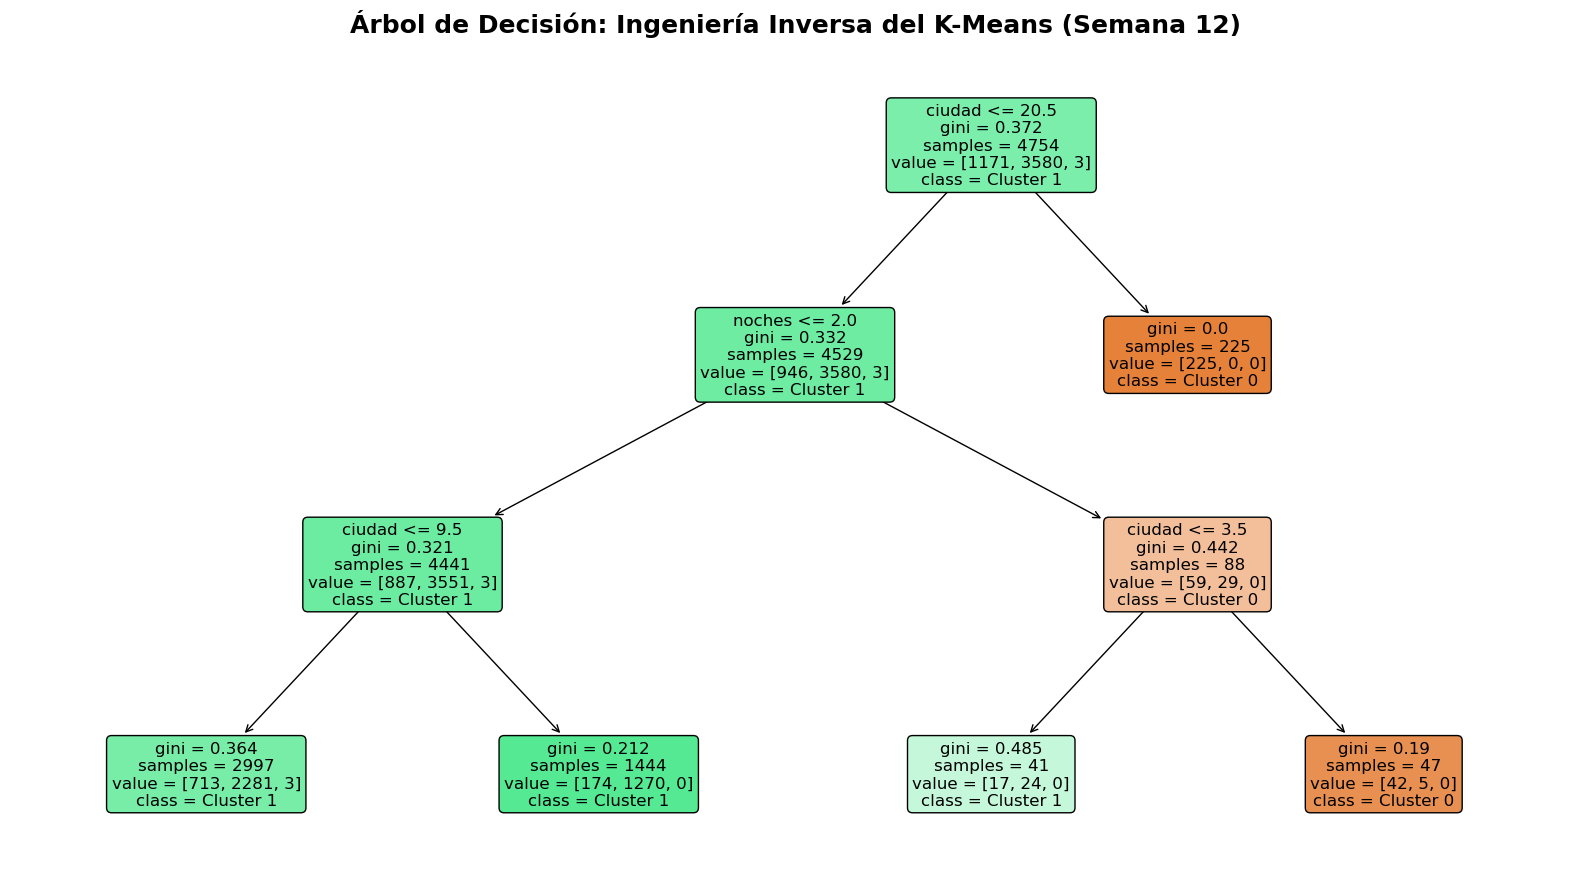

In [11]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# =======================================================================
# 1. ENTRENAMIENTO DEL MODELO REAL EN PYSPARK
# =======================================================================

# Usamos solo noches y ciudad para evitar que el modelo haga trampa
variables_reales = ["noches", "ciudad"]

# Le ponemos un nombre único a la salida para que JAMÁS choque (evita el IllegalArgumentException)
assembler_final = VectorAssembler(inputCols=variables_reales, outputCol="features_finales_arbol")
df_vectorized = assembler_final.transform(df_supervisado)

# Dividimos los datos
train_data, test_data = df_vectorized.randomSplit([0.8, 0.2], seed=42)

# Configuramos y entrenamos el árbol en Spark
dt = DecisionTreeClassifier(featuresCol="features_finales_arbol", labelCol="label", maxDepth=5, seed=42)
dt_model = dt.fit(train_data)

# Predecimos
predictions_supervisadas = dt_model.transform(test_data)

# Evaluamos la precisión
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print("\n========================================")
print(f"Precisión del Árbol (Accuracy): {accuracy * 100:.2f}%")
print("========================================\n")


# =======================================================================
# 2. GRÁFICO VISUAL DEL ÁRBOL (INGENIERÍA INVERSA)
# =======================================================================

# Pasamos solo las variables necesarias a Pandas
df_pandas = df_supervisado.select("noches", "ciudad", "label").toPandas()

X_muestra = df_pandas[["noches", "ciudad"]]
y_muestra = df_pandas["label"]

# Entrenamos el modelo espejo en Scikit-Learn
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# Dibujamos el gráfico para la entrega
plt.figure(figsize=(16, 9), dpi=100)
plot_tree(sk_dt, 
          feature_names=["noches", "ciudad"], 
          class_names=[f"Cluster {int(float(c))}" for c in sorted(y_muestra.unique())], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Semana 12)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Algoritmo Supervisado: Random Forest (Bosques aleatorios), Support Vector Machine (Máquinas de Vector de Soporte), regresión logística multinomial

In [12]:
# Conectamos el nombre de tu archivo con tu pauta
df_recuperado = df_clusters

# 1. Renombramos 'prediction' (del K-Means) a 'label'
df_supervisado = df_recuperado.withColumnRenamed("prediction", "label")

# 2. Dividimos en 70% entrenamiento y 30% prueba
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

# Forzamos a Jupyter a mostrar los resultados en su formato nativo
{
    "Registros de Entrenamiento": train_data.count(),
    "Registros de Prueba": test_data.count()
}

{'Registros de Entrenamiento': 3391, 'Registros de Prueba': 1363}

In [19]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# ==========================================
# MODELO 1: Random Forest (Bosque Aleatorio)
# ==========================================
# CAMBIO 1: Usamos features_finales_arbol
rf = RandomForestClassifier(featuresCol="features_finales_arbol", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# ==========================================
# MODELO 2: SVM (Máquina de Vectores de Soporte)
# ==========================================
# CAMBIO 2 y 3: Usamos features_finales_arbol aquí también
svm_binario = LinearSVC(featuresCol="features_finales_arbol", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="features_finales_arbol")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# ==========================================
# MODELO 3: Regresión Logística Multinomial
# ==========================================
# CAMBIO 4: Usamos features_finales_arbol aquí también
lr = LogisticRegression(featuresCol="features_finales_arbol", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)


In [20]:
# Agregamos esto al final para que te imprima la tablita con los resultados reales en pantalla
print("==================================================")
print("  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  ")
print("==================================================")
print(f"1. Random Forest Accuracy:      {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{accuracy_lr * 100:.2f}%")
print("==================================================")

  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  
1. Random Forest Accuracy:      83.10%
2. SVM (OneVsRest) Accuracy:    77.39%
3. Regresión Logística Accuracy:77.39%
